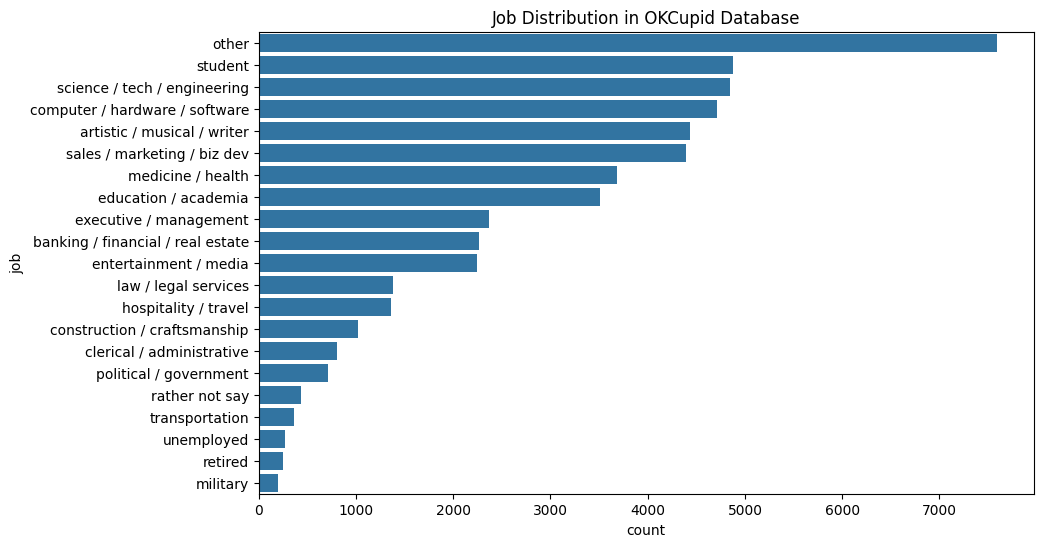

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('profiles.csv')

#Let's see the total count for each job category
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='job', order=df['job'].value_counts().index)
plt.title('Job Distribution in OKCupid Database')
plt.show()

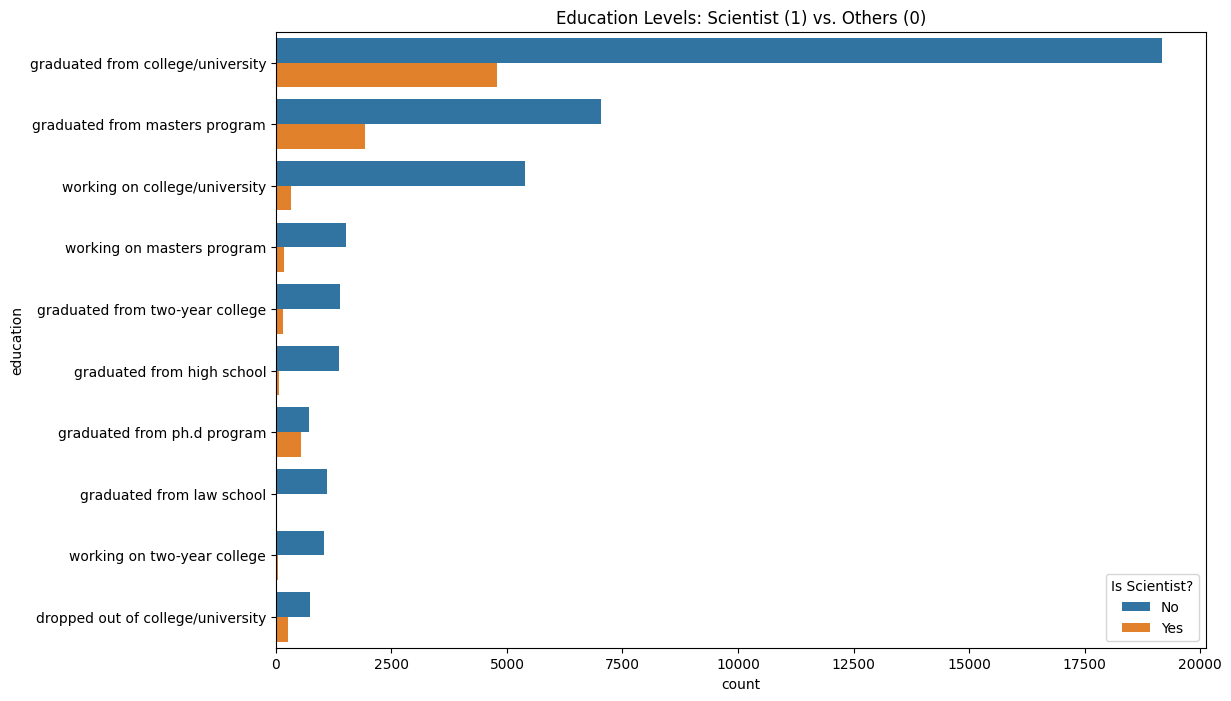

In [4]:
stem_categories = ['science / tech / engineering', 'computer / hardware / software']
df['is_scientist'] = df['job'].apply(lambda x: 1 if x in stem_categories else 0)

plt.figure(figsize=(12,8))
sns.countplot(data=df, y='education', hue='is_scientist',
              order=df['education'].value_counts().index[:10])
plt.title('Education Levels: Scientist (1) vs. Others (0)')
plt.legend(title='Is Scientist?', labels=['No', 'Yes'])
plt.show()

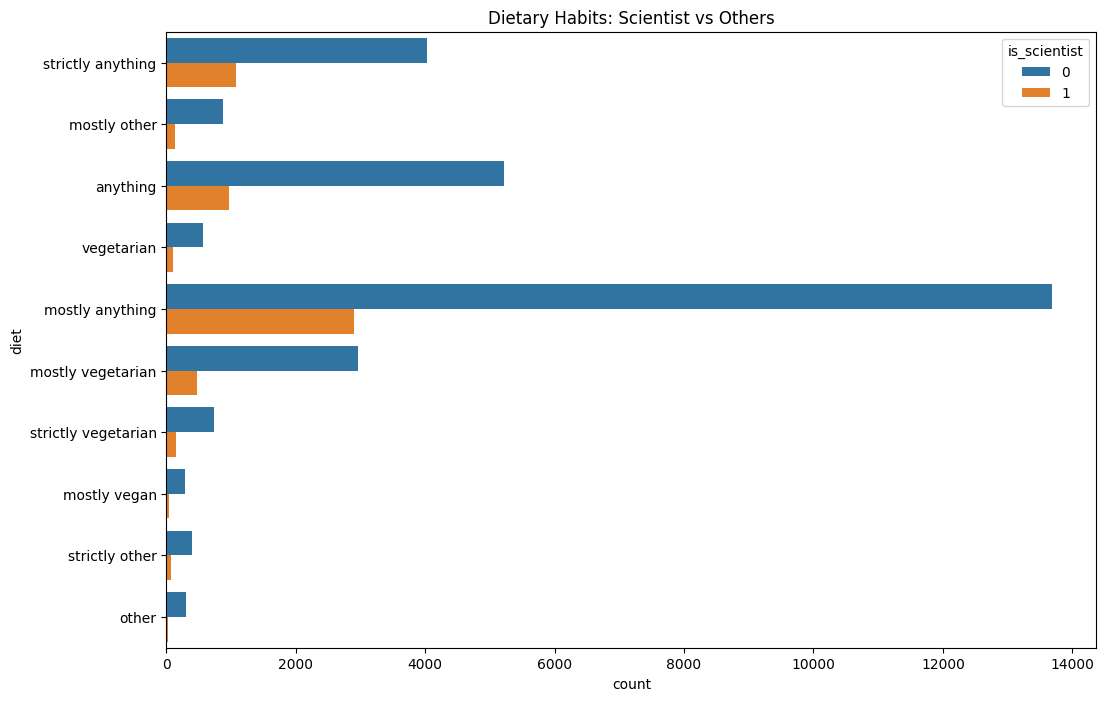

In [7]:
plt.figure(figsize=(12, 8))

top_diets = df['diet'].value_counts().index[:10]
plot_df = df[df['diet'].isin(top_diets)]

sns.countplot(data=plot_df, y='diet', hue='is_scientist')
plt.title('Dietary Habits: Scientist vs Others')
plt.show()

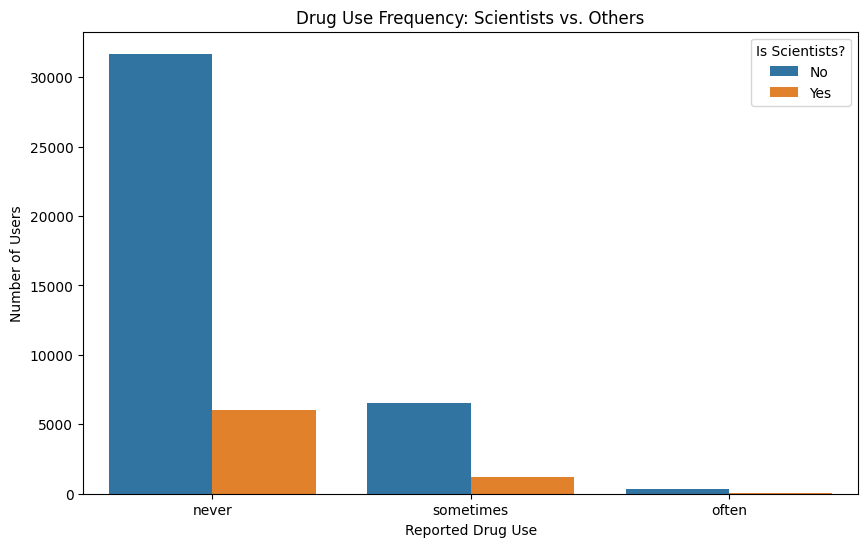

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='drugs', hue='is_scientist')

plt.title('Drug Use Frequency: Scientists vs. Others')
plt.xlabel('Reported Drug Use')
plt.ylabel('Number of Users')
plt.legend(title='Is Scientists?', labels=['No', 'Yes'])
plt.show()

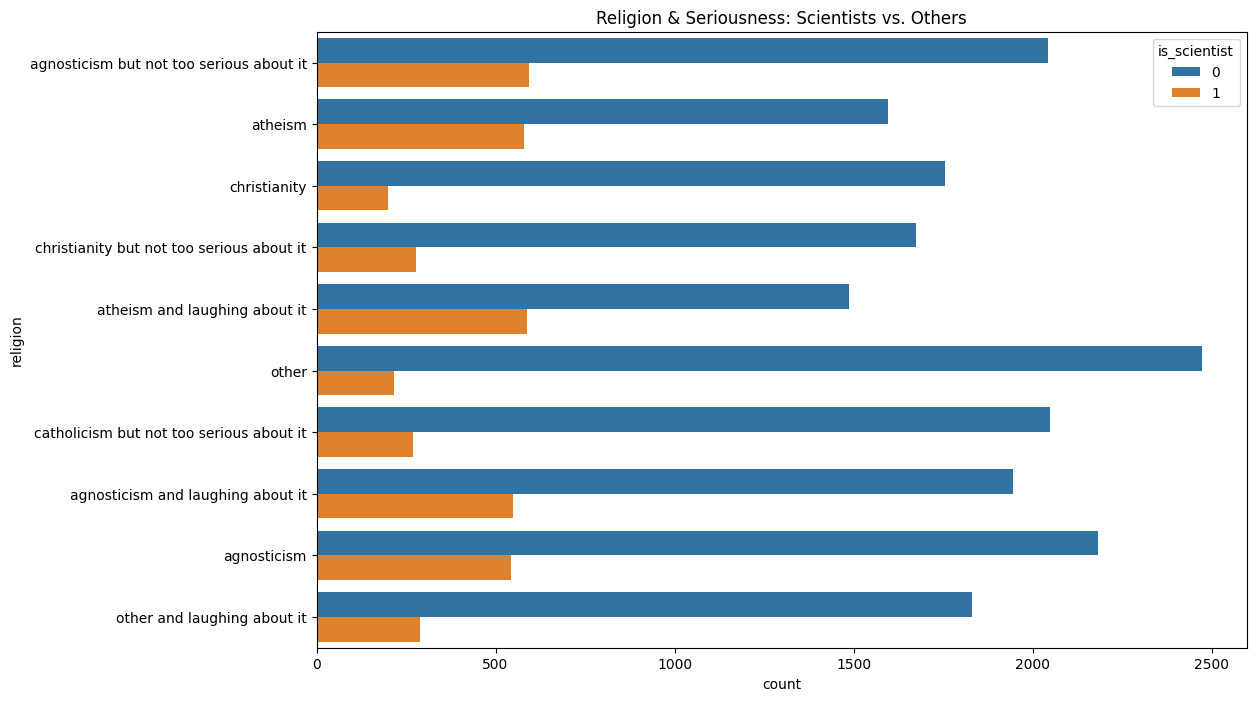

In [9]:
plt.figure(figsize=(12, 8))

# Get the top 10 religion entries
top_religions = df['religion'].value_counts().index[:10]
rel_plot_df = df[df['religion'].isin(top_religions)]

sns.countplot(data=rel_plot_df, y='religion', hue='is_scientist')
plt.title('Religion & Seriousness: Scientists vs. Others')
plt.show()

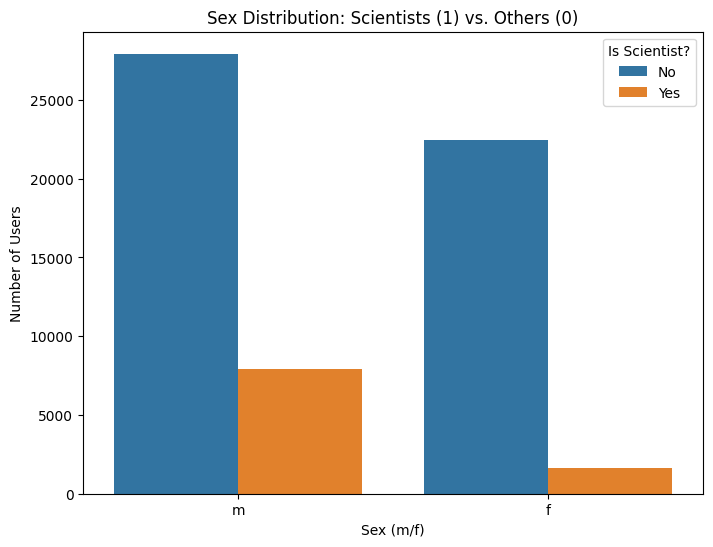

In [10]:
plt.figure(figsize=(8, 6))

# Simple countplot comparing Sex vs. Is Scientist
sns.countplot(data=df, x='sex', hue='is_scientist')

plt.title('Sex Distribution: Scientists (1) vs. Others (0)')
plt.xlabel('Sex (m/f)')
plt.ylabel('Number of Users')
plt.legend(title='Is Scientist?', labels=['No', 'Yes'])
plt.show()

/tmp/ipykernel_8283/1911981422.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['is_scientist'] == 0]['age'], label='Not Scientist', shade=True)
/tmp/ipykernel_8283/1911981422.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['is_scientist'] == 1]['age'], label='Scientist', shade=True)


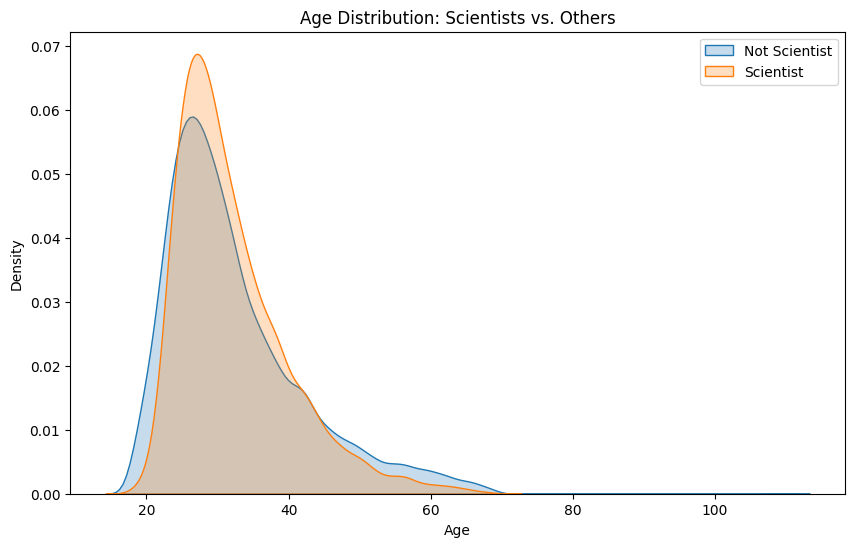

In [11]:
plt.figure(figsize=(10, 6))

# Plotting the age distribution for both groups
sns.kdeplot(df[df['is_scientist'] == 0]['age'], label='Not Scientist', shade=True)
sns.kdeplot(df[df['is_scientist'] == 1]['age'], label='Scientist', shade=True)

plt.title('Age Distribution: Scientists vs. Others')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [12]:
# 1. Cleaning Education: Map complex strings to simple categories
def clean_edu(text):
    if pd.isnull(text): return "unknown"
    if "graduated from" in text: return "graduated"
    if "working on" in text: return "student"
    if "dropped out" in text: return "dropout"
    return "other"

df['edu_clean'] = df['education'].apply(clean_edu)

# 2. Cleaning Religion: Just take the first word (e.g., "Agnosticism")
df['rel_clean'] = df['religion'].str.split().str.get(0).fillna("unknown")

# 3. Filling Missing Drugs: Assume "unknown" for missing values
df['drugs'] = df['drugs'].fillna("unknown")

# 4. Final check of our clean columns
print(df[['edu_clean', 'rel_clean', 'drugs']].head())

   edu_clean    rel_clean      drugs
0    student  agnosticism      never
1    student  agnosticism  sometimes
2  graduated      unknown    unknown
3    student      unknown    unknown
4  graduated      unknown      never


In [13]:
# 1. Select the features we want to use
feature_cols = ['age', 'sex', 'drugs', 'edu_clean', 'rel_clean']
data_subset = df[feature_cols].dropna() # Ensure no NaNs are left

# 2. One-Hot Encoding (The Dummies)
# This turns categories into 0s and 1s
X = pd.get_dummies(data_subset, columns=['sex', 'drugs', 'edu_clean', 'rel_clean'])

# 3. Scaling Age (Normalization)
# We squash age to be between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X['age'] = scaler.fit_transform(X[['age']])

# 4. Define our Target (y)
# We need to make sure y matches the rows we kept in X
y = df.loc[X.index, 'is_scientist']

print(f"Feature Matrix Shape: {X.shape}")
print(X.head())

Feature Matrix Shape: (59946, 22)
        age  sex_f  sex_m  drugs_never  drugs_often  drugs_sometimes  \
0  0.043478  False   True         True        False            False   
1  0.184783  False   True        False        False             True   
2  0.217391  False   True        False        False            False   
3  0.054348  False   True        False        False            False   
4  0.119565  False   True         True        False            False   

   drugs_unknown  edu_clean_dropout  edu_clean_graduated  edu_clean_other  \
0          False              False                False            False   
1          False              False                False            False   
2           True              False                 True            False   
3           True              False                False            False   
4          False              False                 True            False   

   ...  rel_clean_agnosticism  rel_clean_atheism  rel_clean_buddhism  

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} profiles.")
print(f"Testing on {len(X_test)} profiles.")

Training on 47956 profiles.
Testing on 11990 profiles.


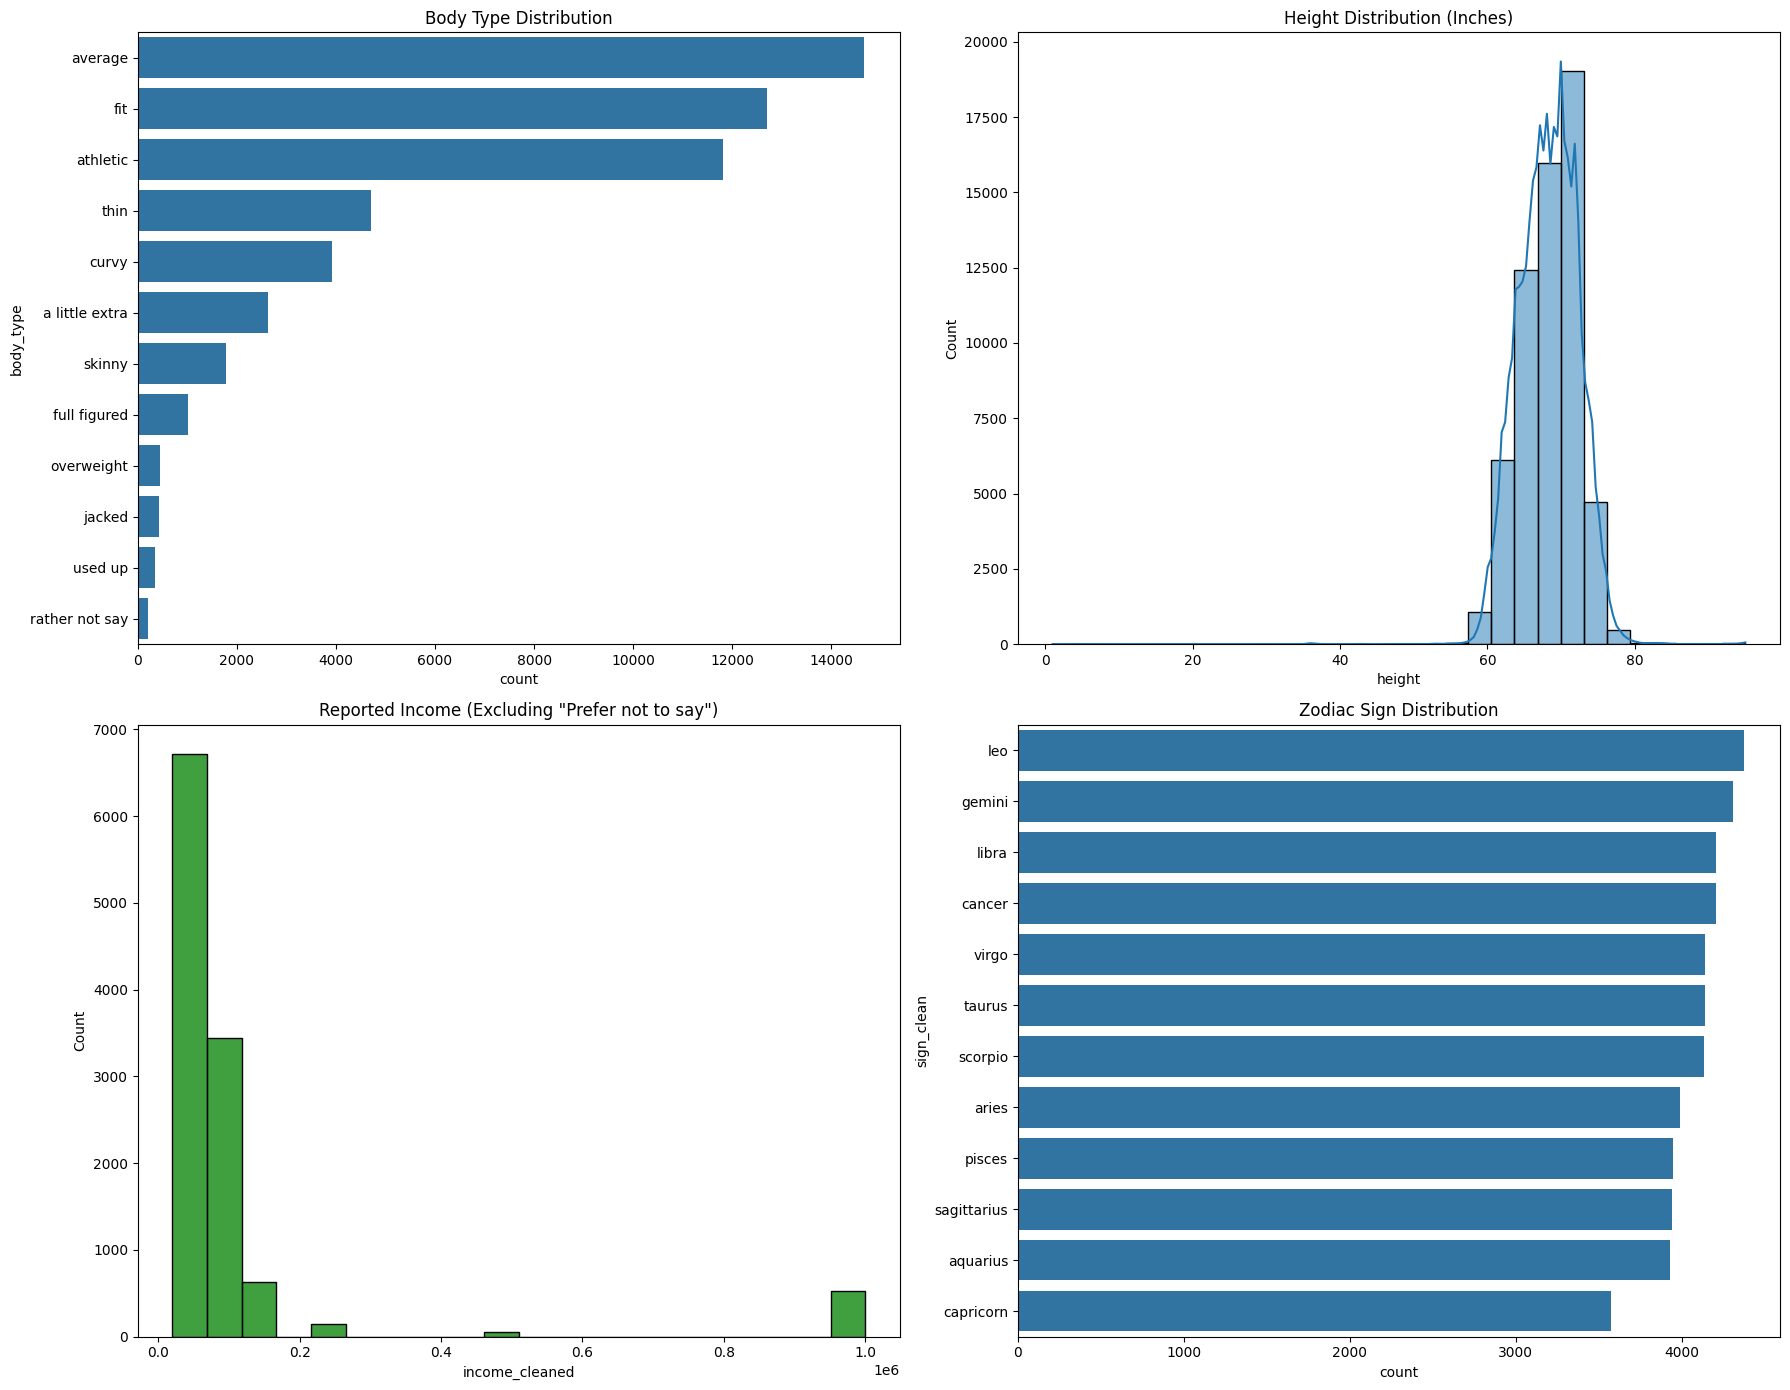

In [15]:
import numpy as np

# 1. Cleaning Income: The dataset uses -1 for "Prefer not to say"
# Let's replace -1 with NaN so the graph doesn't get skewed
df['income_cleaned'] = df['income'].replace(-1, np.nan)

# 2. Cleaning Zodiac: Extracting just the sign (e.g., "Virgo")
df['sign_clean'] = df['sign'].str.split().str.get(0)

# 3. Create the Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Body Type
sns.countplot(data=df, y='body_type', ax=axes[0,0], order=df['body_type'].value_counts().index)
axes[0,0].set_title('Body Type Distribution')

# Plot 2: Height (Distribution)
sns.histplot(df['height'].dropna(), bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title('Height Distribution (Inches)')

# Plot 3: Income (Excluding -1)
sns.histplot(df['income_cleaned'].dropna(), bins=20, ax=axes[1,0], color='green')
axes[1,0].set_title('Reported Income (Excluding "Prefer not to say")')

# Plot 4: Zodiac Sign
sns.countplot(data=df, y='sign_clean', ax=axes[1,1], order=df['sign_clean'].value_counts().index)
axes[1,1].set_title('Zodiac Sign Distribution')

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Start with a fresh copy and drop rows where essential data is missing
# We focus on the columns you requested
master_df = df[['age', 'sex', 'religion', 'diet', 'education', 'job']].dropna()

# 2. Clean 'Religion' and 'Education' to reduce the number of columns
master_df['religion_clean'] = master_df['religion'].str.split().str.get(0)
master_df['edu_clean'] = master_df['education'].apply(lambda x: "graduated" if "graduated from" in str(x) else "other")

# 3. Create the Target (The 'y' variable)
# 1 = Scientist (STEM), 0 = Others
stem_categories = ['science / tech / engineering', 'computer / hardware / software']
y = master_df['job'].apply(lambda x: 1 if x in stem_categories else 0)

# 4. Create the Feature Matrix (The 'X' variable) using Get Dummies
# We drop 'job' and the old 'religion'/'education' columns
features = master_df[['age', 'sex', 'religion_clean', 'diet', 'edu_clean']]
X = pd.get_dummies(features, columns=['sex', 'religion_clean', 'diet', 'edu_clean'])

# 5. Scale the Age so it is between 0 and 1
scaler = MinMaxScaler()
X['age'] = scaler.fit_transform(X[['age']])

# 6. Preview the Master Table
print(f"Master Table created with {X.shape[1]} features (columns).")
print(X.head())

Master Table created with 32 features (columns).
        age  sex_f  sex_m  religion_clean_agnosticism  religion_clean_atheism  \
0  0.043956  False   True                        True                   False   
1  0.186813  False   True                        True                   False   
5  0.120879  False   True                       False                    True   
7  0.142857   True  False                       False                   False   
9  0.208791  False   True                       False                    True   

   religion_clean_buddhism  religion_clean_catholicism  \
0                    False                       False   
1                    False                       False   
5                    False                       False   
7                    False                       False   
9                    False                       False   

   religion_clean_christianity  religion_clean_hinduism  religion_clean_islam  \
0                        False    

In [17]:
print("Target Breakdown:")
print(y.value_counts(normalize=True)) # This shows the percentage of each

Target Breakdown:
job
0    0.808514
1    0.191486
Name: proportion, dtype: float64


In [18]:
# Focus on the numerical columns first (Age and your Target)
stats_summary = df[['age', 'is_scientist']].describe()

# Add the Median (50%) and Range (Max - Min)
stats_summary.loc['median'] = [df['age'].median(), df['is_scientist'].median()]
stats_summary.loc['range'] = [df['age'].max() - df['age'].min(), 1]

print("--- Descriptive Statistics ---")
print(stats_summary)

--- Descriptive Statistics ---
                 age  is_scientist
count   59946.000000  59946.000000
mean       32.340290      0.159427
std         9.452779      0.366077
min        18.000000      0.000000
25%        26.000000      0.000000
50%        30.000000      0.000000
75%        37.000000      0.000000
max       110.000000      1.000000
median     30.000000      0.000000
range      92.000000      1.000000


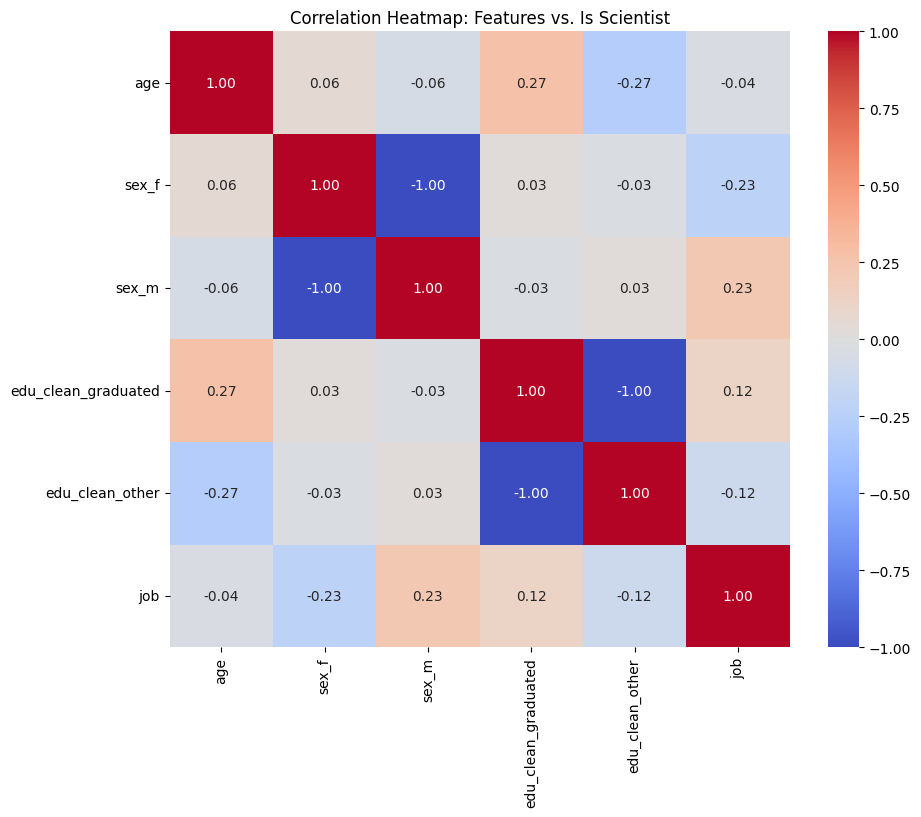

In [19]:
# We'll take a subset of features to keep the heatmap readable
# Let's look at Age and a few encoded columns
corr_cols = ['age'] + [col for col in X.columns if 'edu' in col or 'sex' in col][:5]
corr_matrix = X[corr_cols].join(y).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Features vs. Is Scientist')
plt.show()

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model using your training data
knn.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred = knn.predict(X_test)

# 4. See the results
print("--- K-Nearest Neighbors (k=5) Results ---")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

--- K-Nearest Neighbors (k=5) Results ---
[[9509  570]
 [1658  253]]
              precision    recall  f1-score   support

           0       0.85      0.94      0.90     10079
           1       0.31      0.13      0.19      1911

    accuracy                           0.81     11990
   macro avg       0.58      0.54      0.54     11990
weighted avg       0.76      0.81      0.78     11990



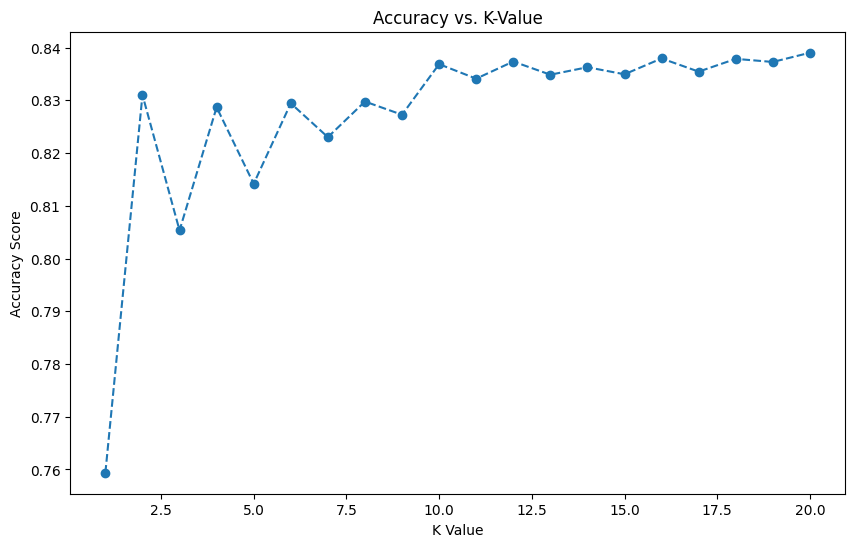

In [23]:
scores = []
for k in range(1, 21):
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train, y_train)
    scores.append(classifier.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), scores, marker='o', linestyle='dashed')
plt.title('Accuracy vs. K-Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy Score')
plt.show()

In [24]:
# Run this for your best K
best_k = 20 # or whatever your highest value was
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[9989   90]
 [1840   71]]


In [25]:
from sklearn.naive_bayes import MultinomialNB

# 1. Initialize and Train
# Note: MNB works well with our 0/1 One-Hot encoded data!
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# 2. Predict and Evaluate
nb_pred = nb_model.predict(X_test)

print("--- Multinomial Naive Bayes Results ---")
print(classification_report(y_test, nb_pred))

--- Multinomial Naive Bayes Results ---
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     10079
           1       0.36      0.00      0.00      1911

    accuracy                           0.84     11990
   macro avg       0.60      0.50      0.46     11990
weighted avg       0.76      0.84      0.77     11990



In [26]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the SVM Model
# We use 'linear' kernel first; 'rbf' is another common one for complex data
svm_model = SVC(kernel='linear', random_state=42)

# 2. Train the model
svm_model.fit(X_train, y_train)

# 3. Make predictions
svm_pred = svm_model.predict(X_test)

# 4. Evaluate the results
print("--- Support Vector Machine (Linear) Results ---")
print(classification_report(y_test, svm_pred))

--- Support Vector Machine (Linear) Results ---
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     10079
           1       0.00      0.00      0.00      1911

    accuracy                           0.84     11990
   macro avg       0.42      0.50      0.46     11990
weighted avg       0.71      0.84      0.77     11990



/home/alien/Documents/OKCupid-Date-A-Scientist-Starter/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alien/Documents/OKCupid-Date-A-Scientist-Starter/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alien/Documents/OKCupid-Date-A-Scientist-Starter/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

In [27]:
# 'balanced' automatically adjusts weights inversely proportional to class frequencies
svm_weighted = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_weighted.fit(X_train, y_train)
svm_weighted_pred = svm_weighted.predict(X_test)

print("--- Weighted SVM Results ---")
print(classification_report(y_test, svm_weighted_pred))

--- Weighted SVM Results ---
              precision    recall  f1-score   support

           0       0.92      0.64      0.75     10079
           1       0.27      0.71      0.39      1911

    accuracy                           0.65     11990
   macro avg       0.60      0.67      0.57     11990
weighted avg       0.82      0.65      0.70     11990



In [30]:
# 1. Create the cleaned religion column in the main dataframe
df['religion_clean'] = df['religion'].str.split().str.get(0)

# 2. Now run the regression prep again
reg_df = df[['age', 'sex', 'religion_clean']].dropna()

# 3. Create Dummies
X_reg = pd.get_dummies(reg_df[['sex', 'religion_clean']], drop_first=True)
X_reg = sm.add_constant(X_reg)
y_reg = reg_df['age']

# 4. Fit and Summary
model = sm.OLS(y_reg, X_reg.astype(float)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    age   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     177.7
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        08:58:16   Log-Likelihood:            -1.4672e+05
No. Observations:               39720   AIC:                         2.935e+05
Df Residuals:                   39710   BIC:                         2.935e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# 1. Initialize a clean Linear Regression model
lr = LinearRegression()

# 2. Use our X_reg (features) and y_reg (age) from the previous step
# We perform 5-fold cross-validation
cv_scores = cross_val_score(lr, X_reg, y_reg, cv=5, scoring='r2')

# 3. Display the results
print("--- 5-Fold Cross-Validation (R-squared) ---")
print(f"Scores for each fold: {cv_scores}")
print(f"Mean R-squared: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

--- 5-Fold Cross-Validation (R-squared) ---
Scores for each fold: [0.03115089 0.03673633 0.03454704 0.03899619 0.03870943]
Mean R-squared: 0.0360
Standard Deviation: 0.0029


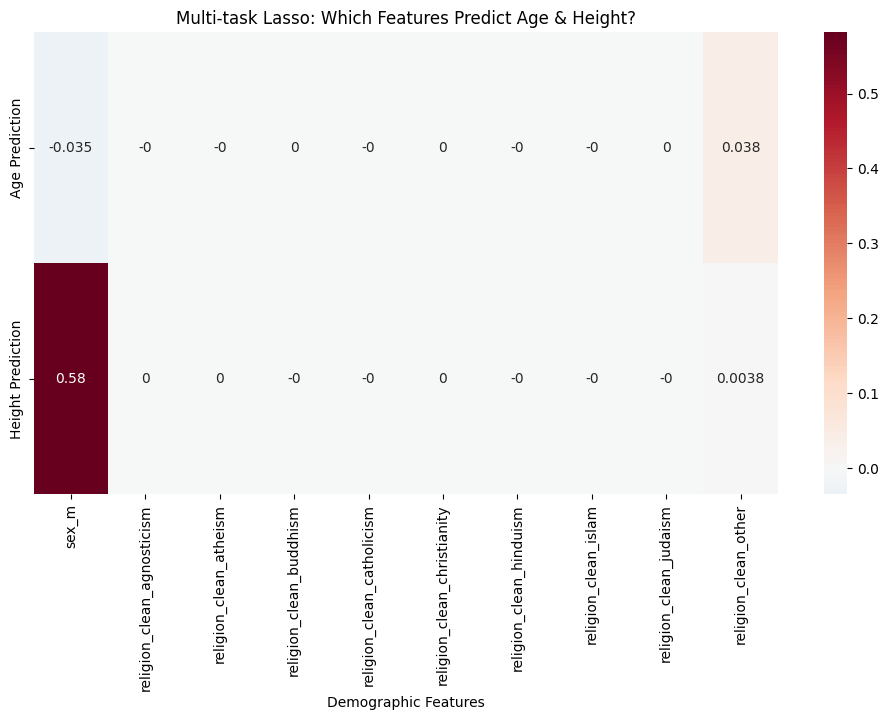

In [32]:
from sklearn.linear_model import MultiTaskLasso
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean data and handle outliers for Height
# We filter height to a realistic range (55 to 80 inches)
lasso_df = df[(df['height'] > 55) & (df['height'] < 80)].copy()
lasso_df['religion_clean'] = lasso_df['religion'].str.split().str.get(0).fillna('Unknown')

# 2. Define Features (X) and Targets (Y)
X = pd.get_dummies(lasso_df[['sex', 'religion_clean']], drop_first=True)
Y = lasso_df[['age', 'height']]

# 3. Scaling is MANDATORY for Lasso
# Lasso relies on the size of coefficients, so all features must be on the same scale
scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X)

scaler_y = StandardScaler()
Y_scaled = scaler_y.fit_transform(Y)

# 4. Fit the Multi-task Lasso
# alpha=0.1 is the 'strength' of the penalty. Higher alpha = fewer features survive.
mtl = MultiTaskLasso(alpha=0.1)
mtl.fit(X_scaled, Y_scaled)

# 5. Create the Chart
coef_df = pd.DataFrame(mtl.coef_, index=['Age Prediction', 'Height Prediction'], columns=X.columns)

plt.figure(figsize=(12, 6))
sns.heatmap(coef_df, annot=True, cmap='RdBu_r', center=0)
plt.title('Multi-task Lasso: Which Features Predict Age & Height?')
plt.xlabel('Demographic Features')
plt.show()

In [35]:
# 1. Create a fresh slice with all the columns we need
final_df = df[['age', 'sex', 'religion_clean', 'diet', 'edu_clean', 'is_scientist']].dropna()

# 2. Re-create the Target (y)
y = final_df['is_scientist']

# 3. Re-create the Feature Matrix (X)
# We select the features and then One-Hot Encode
features = final_df[['age', 'sex', 'religion_clean', 'diet', 'edu_clean']]
X = pd.get_dummies(features, columns=['sex', 'religion_clean', 'diet', 'edu_clean'])

# 4. Re-Scale the Age
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X['age'] = scaler.fit_transform(X[['age']])

# 5. Verify the lengths match
print(f"X rows: {len(X)}, y rows: {len(y)}")

X rows: 25403, y rows: 25403


In [36]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

# Initialize with balanced weights to handle the 'Scientist' minority
svm_cv = SVC(kernel='linear', class_weight='balanced', random_state=42)

# Run 5-Fold CV using F1-score
cv_f1_scores = cross_val_score(svm_cv, X, y, cv=5, scoring='f1')

print("--- 5-Fold SVM Cross-Validation (F1-Score) ---")
print(f"F1 Scores: {cv_f1_scores}")
print(f"Mean F1: {cv_f1_scores.mean():.4f}")

--- 5-Fold SVM Cross-Validation (F1-Score) ---
F1 Scores: [0.40741849 0.39265537 0.41508314 0.40207373 0.42513626]
Mean F1: 0.4085


In [37]:
# 1. Fit the model to the full clean dataset
svm_cv.fit(X, y)

# 2. Extract weights (coefficients)
weights = pd.Series(svm_cv.coef_[0], index=X.columns)

# 3. Display the insights
print("--- 🔬 Top STEM Predictors ---")
print(weights.sort_values(ascending=False).head(5))

print("\n--- 🎨 Top NON-STEM Predictors ---")
print(weights.sort_values(ascending=True).head(5))

--- 🔬 Top STEM Predictors ---
sex_m                  0.999957
edu_clean_graduated    0.400099
edu_clean_dropout      0.400085
edu_clean_other        0.399870
edu_clean_unknown      0.399652
dtype: float64

--- 🎨 Top NON-STEM Predictors ---
edu_clean_student   -1.599706
diet_halal          -1.216153
sex_f               -0.999957
diet_vegan          -0.982350
diet_kosher         -0.608076
dtype: float64


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler

# 1. LOAD: Bring the raw data back into memory
# Make sure 'profiles.csv' is in your current folder!
df = pd.read_csv('profiles.csv')

# 2. PRE-PROCESS: Clean the 'religion' and 'education' columns
df['religion_clean'] = df['religion'].str.split().str.get(0)
df['edu_clean'] = df['education'].str.split().str.get(0)

# 3. RE-ALIGN: Create a clean slice where X and y match perfectly
final_df = df[['age', 'sex', 'religion_clean', 'diet', 'edu_clean', 'job']].dropna()

# 4. DEFINE TARGET: Is the job in STEM? 
stem_jobs = ['science / tech / engineering', 'computer / hardware / software']
y = final_df['job'].isin(stem_jobs).astype(int)

# 5. DEFINE FEATURES: One-Hot Encoding
features = final_df[['age', 'sex', 'religion_clean', 'diet', 'edu_clean']]
X = pd.get_dummies(features, drop_first=True)

# 6. SCALE: Age needs to be between 0 and 1 for the SVM
scaler = MinMaxScaler()
X['age'] = scaler.fit_transform(X[['age']])

# 7. SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data Loaded and Synced! Training on {X_train.shape[0]} profiles...")

# 8. TUNE: The final Grid Search
param_grid = {
    'C': [0.1, 1], 
    'kernel': ['linear', 'rbf']
}
grid = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=3, scoring='f1')
grid.fit(X_train, y_train)

print("\n--- 🏆 Optimized Model Results ---")
print(f"Best Parameters: {grid.best_params_}")
print(f"Best F1-Score: {grid.best_score_:.4f}")

Data Loaded and Synced! Training on 18115 profiles...

--- 🏆 Optimized Model Results ---
Best Parameters: {'C': 0.1, 'kernel': 'rbf'}
Best F1-Score: 0.4371


--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Non-STEM       0.91      0.58      0.71      3685
        STEM       0.29      0.75      0.42       844

    accuracy                           0.61      4529
   macro avg       0.60      0.66      0.56      4529
weighted avg       0.79      0.61      0.65      4529



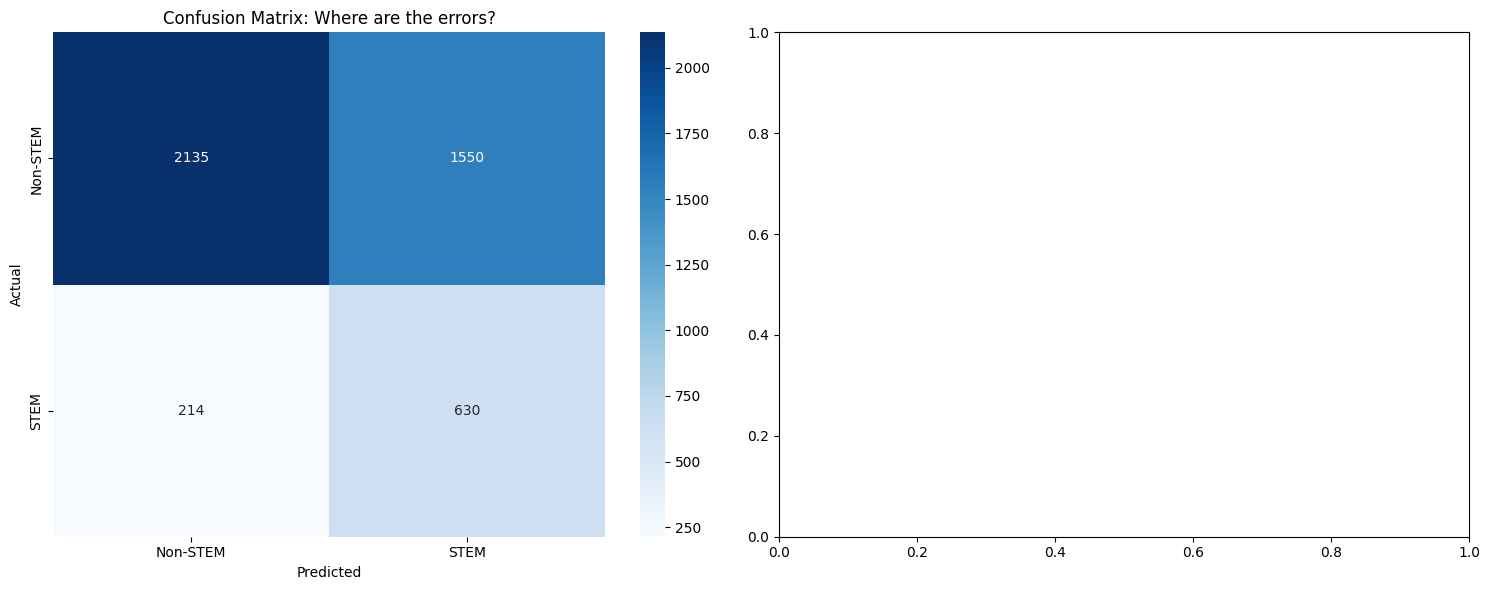

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve

# 1. Get predictions from your best model (the grid object)
y_pred = grid.predict(X_test)

# 2. Setup the Plotting Layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- PLOT 1: Confusion Matrix ---
# This shows: Did we miss scientists (False Negatives) or over-predict them (False Positives)?
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Non-STEM', 'STEM'], yticklabels=['Non-STEM', 'STEM'])
ax1.set_title('Confusion Matrix: Where are the errors?')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# --- PLOT 2: Classification Report Summary ---
# We use a text-based report to see the balance of Precision vs. Recall
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Non-STEM', 'STEM']))

# --- PLOT 3: Precision-Recall Curve (Optional if you have probability=True) ---
# If you didn't enable probability, the code below might need to be skipped.
# from sklearn.metrics import PrecisionRecallDisplay
# PrecisionRecallDisplay.from_estimator(grid, X_test, y_test, ax=ax2)
# ax2.set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

/home/alien/Documents/OKCupid-Date-A-Scientist-Starter/venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


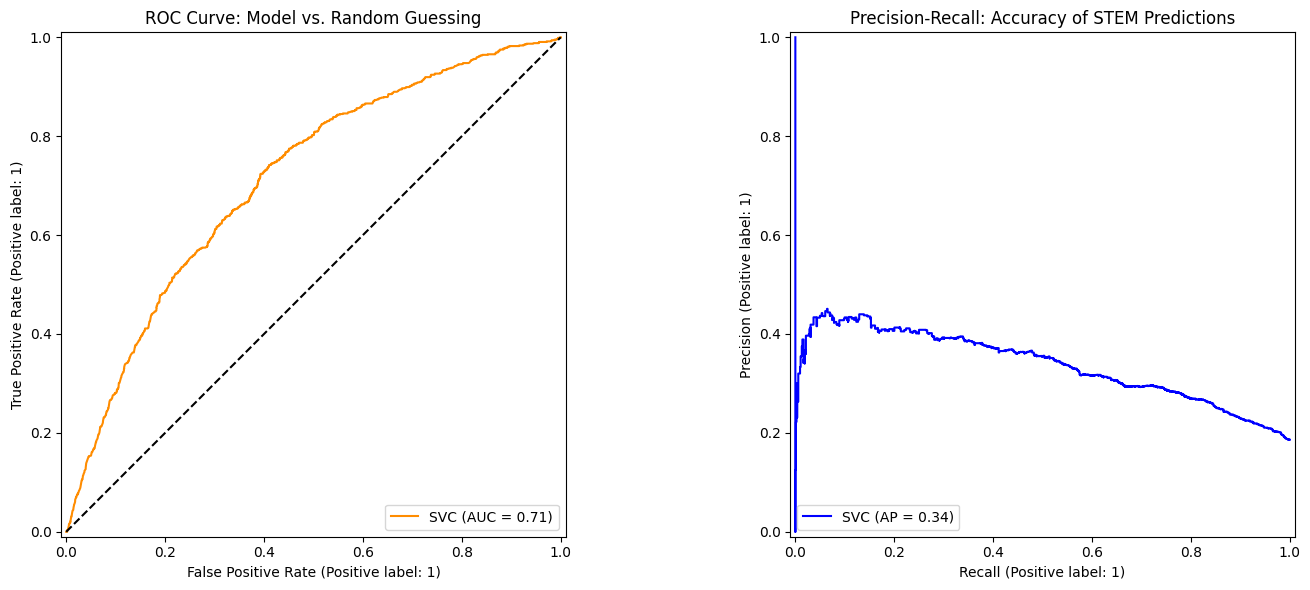

In [9]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# 1. Re-initialize the BEST model with probability enabled
# We use the parameters your GridSearch found: C=0.1, kernel='rbf'
best_svm = SVC(C=0.1, kernel='rbf', class_weight='balanced', probability=True, random_state=42)
best_svm.fit(X_train, y_train)

# 2. Setup the Plotting Layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- PLOT 1: ROC Curve ---
# This shows the trade-off between catching scientists vs. accidentally picking non-scientists
RocCurveDisplay.from_estimator(best_svm, X_test, y_test, ax=ax1, color='darkorange')
ax1.plot([0, 1], [0, 1], 'k--', label='Random Guess') # The 'Baseline' diagonal
ax1.set_title('ROC Curve: Model vs. Random Guessing')

# --- PLOT 2: Precision-Recall Curve ---
# This is actually MORE important for your project because scientists are a minority!
PrecisionRecallDisplay.from_estimator(best_svm, X_test, y_test, ax=ax2, color='blue')
ax2.set_title('Precision-Recall: Accuracy of STEM Predictions')

plt.tight_layout()
plt.show()